# BNN Multimodal

Entraînement du modèle central du memoire : un réseau bayésien (BNN) combinant les features visuelles d'un ResNet18 gelé (512 dim) avec la feature clinique d'âge cérébral prédit (32 dim via MLP), soit 544 features en entrée de la tête bayésienne.

**Prérequis :** `runs_cnn_baseline/best_final.pt` (notebook 01) et `predicted_clinical.pkl` (notebook 02).

**Rôle dans le pipeline :** modèle principal analysé dans les notebooks 04 (incertitude, calibration) et 05 (Grad-CAM). Inclut une étude d'ablation (image seule vs multimodal) pour quantifier la contribution de la feature clinique.

**Sortie :** `runs_bnn_multimodal/best.pt` et `runs_bnn_multimodal/ablation_image_only.pt`.

### Imports & seed 

In [1]:
import os, random, glob, re
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             confusion_matrix, classification_report)
from PIL import Image
import matplotlib.pyplot as plt
import pickle

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


### Chemins & hyperparamètres

In [2]:
DATAROOT    = "/Users/teodul/Documents/Memoire/Epic and CSCR hospital Dataset"
TRAIN_DIR   = os.path.join(DATAROOT, "Train")
TEST_DIR    = os.path.join(DATAROOT, "Test")
CNN_CKPT    = "runs_cnn_baseline/best_final.pt"
SAVE_DIR    = "runs_bnn_multimodal"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 1e-3
NUM_WORKERS = 0
PATIENCE    = 3
MC_PASSES   = 50
KL_WEIGHT   = 0.01
CLASSES     = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = 4

### Dataset multimodal

In [3]:
with open("predicted_clinical.pkl", "rb") as f:
    predicted_clinical = pickle.load(f)

class MultimodalBrainDataset(Dataset):
    def __init__(self, rootdir, transform, split=None, classes=CLASSES, samples=None):
        self.transform = transform
        self.classes = classes

        if samples is not None:
            self.samples = list(samples)
        else:
            self.samples = []
            for idx, cls in enumerate(classes):
                clsdir = os.path.join(rootdir, cls)
                for ext in ['.jpg', '.jpeg', '.png']:
                    for path in sorted(glob.glob(os.path.join(clsdir, f'*{ext}'))):
                        clin = predicted_clinical[split].get(path, np.array([0.5], dtype=np.float32))
                        self.samples.append((path, idx, cls, clin))
            random.shuffle(self.samples)

        counts = np.bincount([s[1] for s in self.samples])
        print(f"Dataset - {len(self.samples)} images")
        print("  " + ", ".join(f"{c}:{n}" for c, n in zip(classes, counts)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, clsname, clinical = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        clinical = torch.tensor(clinical, dtype=torch.float32)
        return img, clinical, label


train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def get_patient_id(filepath):
    fname = os.path.basename(filepath)
    m = re.match(r'^(?:Tr|Te)-([a-z]{2}_\d+)', fname)
    if m: return m.group(1)
    m = re.match(r'^([A-Z]_\d+)_', fname)
    if m: return m.group(1)
    m = re.match(r'^([A-Z]_\d+)\.', fname)
    if m: return m.group(1)
    m = re.match(r'^(\d+)', fname)
    if m: return m.group(1)
    return fname

all_samples = []
for idx, cls in enumerate(CLASSES):
    clsdir = os.path.join(TRAIN_DIR, cls)
    for ext in ['.jpg', '.jpeg', '.png']:
        for path in sorted(glob.glob(os.path.join(clsdir, f'*{ext}'))):
            clin = predicted_clinical["train"].get(path, np.array([0.5], dtype=np.float32))
            all_samples.append((path, idx, cls, clin))

unmatched = [os.path.basename(p) for p, _, _, _ in all_samples
             if get_patient_id(p) == os.path.basename(p)]
print(f"Fichiers fallback (1 img/patient) : {len(unmatched)} / {len(all_samples)}")

train_samples, val_samples = [], []
rng = np.random.default_rng(SEED)

for cls_idx, cls in enumerate(CLASSES):
    cls_samps = [(p, l, c, cl) for p, l, c, cl in all_samples if l == cls_idx]
    patient_ids = [get_patient_id(p) for p, _, _, _ in cls_samps]
    unique_patients = sorted(set(patient_ids))

    rng.shuffle(unique_patients)
    n_val_p = max(1, int(0.15 * len(unique_patients)))
    val_patients = set(unique_patients[:n_val_p])

    for s, pid in zip(cls_samps, patient_ids):
        (val_samples if pid in val_patients else train_samples).append(s)

random.shuffle(train_samples)

train_ds = MultimodalBrainDataset(None, train_tf, samples=train_samples)
val_ds   = MultimodalBrainDataset(None, val_tf,   samples=val_samples)
test_ds  = MultimodalBrainDataset(TEST_DIR, val_tf, split="test")

print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

labels        = [s[1] for s in train_ds.samples]
counts        = np.bincount(labels)
class_weights = 1.0 / counts
sample_weights = class_weights[labels]
g_gen = torch.Generator(); g_gen.manual_seed(SEED)
sampler = torch.utils.data.WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.double),
    num_samples = len(sample_weights),
    replacement = True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, generator=g_gen)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

Fichiers fallback (1 img/patient) : 964 / 9644
Dataset - 8103 images
  glioma:2537, meningioma:1822, notumor:1648, pituitary:2096
Dataset - 1541 images
  glioma:481, meningioma:361, notumor:291, pituitary:408
Dataset - 2414 images
  glioma:755, meningioma:546, notumor:487, pituitary:626

Train: 8103 | Val: 1541 | Test: 2414


### Architecture multimodale CNN + MLP

In [4]:
class BNNMultimodalNet(nn.Module):
    def __init__(self, num_classes=4, clinical_dim=1,
                 cnn_ckpt=None, prior_mu=0, prior_sigma=0.1):
        super().__init__()

        backbone    = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn    = backbone

        if cnn_ckpt and os.path.exists(cnn_ckpt):
            ckpt     = torch.load(cnn_ckpt, map_location="cpu",
                                  weights_only=False)
            state    = ckpt.get("model_state", ckpt)
            filtered = {k: v for k, v in state.items()
                        if not k.startswith("fc.")}
            self.cnn.load_state_dict(filtered, strict=False)
            print(f"✓ Poids CNN chargés depuis {cnn_ckpt}")
        else:
            print("⚠ Checkpoint non trouvé, poids ImageNet par défaut")

        # on fine-tune seulement les deux derniers blocs ResNet, le reste reste gelé
        for name, param in self.cnn.named_parameters():
            if "layer4" in name or "layer3" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.clinical_mlp = nn.Sequential(
            nn.Linear(clinical_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512 + 32, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )

    def forward(self, img, clinical):
        img_feat      = self.cnn(img)
        clinical_feat = self.clinical_mlp(clinical)
        fused         = torch.cat([img_feat,
                                   clinical_feat], dim=1)
        return self.bnn_head(fused)


model = BNNMultimodalNet(
    num_classes=NUM_CLASSES,
    clinical_dim=1,
    cnn_ckpt=CNN_CKPT,
    prior_mu=0,
    prior_sigma=0.1
).to(device)

trainable = [p for p in model.parameters() if p.requires_grad]
print(f"Params entraînables : {sum(p.numel() for p in trainable):,}")

ce_loss = nn.CrossEntropyLoss()
def kl_loss(model):
    kl = torch.tensor(0.0, device=device)
    for m in model.modules():
        if isinstance(m, bnn.BayesLinear):
            mu        = m.weight_mu
            log_sigma = m.weight_log_sigma
            sigma     = torch.exp(log_sigma)
            prior_mu  = torch.tensor(m.prior_mu, device=device)
            prior_sig = torch.tensor(m.prior_sigma, device=device)
            # KL entre deux gaussiennes, calculée analytiquement
            kl += 0.5 * torch.mean(
                ((mu - prior_mu) ** 2 + sigma ** 2) / (prior_sig ** 2)
                - 1
                + 2 * torch.log(prior_sig)
                - 2 * log_sigma
            )
    return kl

optimizer = torch.optim.Adam(trainable, lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2
)

✓ Poids CNN chargés depuis runs_cnn_baseline/best_final.pt
Params entraînables : 10,845,672


### Évaluation standard

In [5]:
@torch.no_grad()
def evaluate(loader, model, split="Test"):
    model.eval()
    all_y, all_preds, all_probs = [], [], []

    for img, clin, y in loader:
        img, clin = img.to(device), clin.to(device)
        logits = model(img, clin)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_y.extend(y.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

    all_y     = np.array(all_y)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    bal_acc = balanced_accuracy_score(all_y, all_preds)
    auc     = roc_auc_score(all_y, all_probs,
                             multi_class="ovr", average="macro")

    print(f"\n[{split}] bal_acc={bal_acc:.3f}  AUC={auc:.3f}")
    print("Confusion matrix:\n", confusion_matrix(all_y, all_preds))
    print(classification_report(all_y, all_preds,
                                 target_names=CLASSES, digits=3))
    return bal_acc, auc

### Inférence bayésienne

In [6]:
def bayesian_inference(loader, model, n_passes=MC_PASSES, split="BNN"):
    model.eval()
    all_y, all_mean, all_std = [], [], []

    with torch.no_grad():
        for img, clin, y in loader:
            img, clin = img.to(device), clin.to(device)

            passes = torch.stack([
                torch.softmax(model(img, clin), dim=1)
                for _ in range(n_passes)
            ])

            all_y.extend(y.numpy())
            all_mean.extend(passes.mean(dim=0).cpu().numpy())
            all_std.extend(passes.std(dim=0).cpu().numpy())

    all_y    = np.array(all_y)
    all_mean = np.array(all_mean)
    all_std  = np.array(all_std)
    preds    = all_mean.argmax(axis=1)
    # incertitude sur la classe prédite uniquement (pas la moyenne sur toutes)
    pred_std = all_std[np.arange(len(preds)), preds]

    bal_acc = balanced_accuracy_score(all_y, preds)
    auc     = roc_auc_score(all_y, all_mean,
                             multi_class="ovr", average="macro")
    correct = (preds == all_y)

    print(f"\n[{split} x{n_passes}] bal_acc={bal_acc:.3f}  AUC={auc:.3f}")
    print(f"Incertitude globale      : {pred_std.mean():.4f} ± {pred_std.std():.4f}")
    print(f"  Prédictions CORRECTES  : {pred_std[correct].mean():.4f}")
    print(f"  Prédictions INCORRECTES: {pred_std[~correct].mean():.4f}")
    print("Confusion matrix:\n", confusion_matrix(all_y, preds))

    return all_y, all_mean, all_std, preds

### Boucle d'entraînement


In [7]:
history    = {"loss": [], "ce": [], "kl": [], "val_bal_acc": [], "val_auc": []}
best_auc   = -1.0
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses, ces, kls = [], [], []

    for img, clin, y in train_loader:
        img, clin, y = img.to(device), clin.to(device), y.to(device)
        optimizer.zero_grad()

        logits  = model(img, clin)
        ce      = ce_loss(logits, y)
        kl      = kl_loss(model)
        loss    = ce + KL_WEIGHT * kl

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        ces.append(ce.item())
        kls.append(kl.item())

    scheduler.step()

    print(f"\nepoch {epoch:02d}/{EPOCHS}  "
          f"loss={np.mean(losses):.4f}  "
          f"ce={np.mean(ces):.4f}  "
          f"kl={np.mean(kls):.4f}")

    bal_acc, auc = evaluate(val_loader, model, split="Val")

    history["loss"].append(np.mean(losses))
    history["ce"].append(np.mean(ces))
    history["kl"].append(np.mean(kls))
    history["val_bal_acc"].append(bal_acc)
    history["val_auc"].append(auc)

    if auc > best_auc:
        best_auc   = auc
        no_improve = 0
        torch.save({
            "epoch": epoch, "auc": auc, "bal_acc": bal_acc,
            "model_state": model.state_dict(),
        }, f"{SAVE_DIR}/best.pt")
        print(f"  ✓ saved (AUC val={auc:.3f})")
    else:
        no_improve += 1
        print(f"  patience {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print(f"Early stopping à l'epoch {epoch}")
            break

print(f"\nMeilleur AUC val : {best_auc:.3f}")


epoch 01/15  loss=1.6054  ce=1.6031  kl=0.2357

[Val] bal_acc=0.508  AUC=0.702
Confusion matrix:
 [[247  71  67  96]
 [136 155   9  61]
 [ 12  21 201  57]
 [159  83   4 162]]
              precision    recall  f1-score   support

      glioma      0.446     0.514     0.477       481
  meningioma      0.470     0.429     0.449       361
     notumor      0.715     0.691     0.703       291
   pituitary      0.431     0.397     0.413       408

    accuracy                          0.496      1541
   macro avg      0.515     0.508     0.510      1541
weighted avg      0.498     0.496     0.496      1541

  ✓ saved (AUC val=0.702)

epoch 02/15  loss=1.1030  ce=1.1004  kl=0.2582

[Val] bal_acc=0.464  AUC=0.743
Confusion matrix:
 [[ 96 182  15 188]
 [ 46 192   9 114]
 [  2  10 273   6]
 [149 173  10  76]]
              precision    recall  f1-score   support

      glioma      0.328     0.200     0.248       481
  meningioma      0.345     0.532     0.418       361
     notumor      0.889 

### Évaluation BNN finale

In [8]:
ckpt = torch.load(f"{SAVE_DIR}/best.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Meilleur modèle : epoch {ckpt['epoch']}, AUC val={ckpt['auc']:.3f}")

print("\n--- Évaluation finale sur le test set ---")
all_y, all_mean, all_std, preds = bayesian_inference(
    test_loader, model, MC_PASSES
)

Meilleur modèle : epoch 13, AUC val=0.999

--- Évaluation finale sur le test set ---

[BNN x50] bal_acc=0.968  AUC=0.996
Incertitude globale      : 0.0189 ± 0.0436
  Prédictions CORRECTES  : 0.0151
  Prédictions INCORRECTES: 0.1217
Confusion matrix:
 [[702  29  21   3]
 [ 20 515   0  11]
 [  0   0 487   0]
 [  0   1   0 625]]


### Figures incertitude

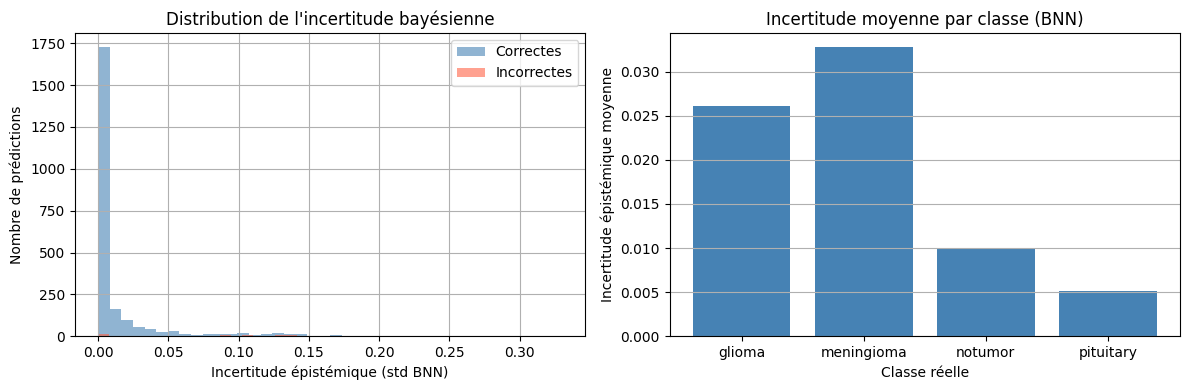

In [9]:
correct  = (preds == all_y)
# incertitude sur la classe prédite uniquement (pas la moyenne sur toutes)
pred_std = all_std[np.arange(len(preds)), preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_std[correct],  bins=40, alpha=0.6,
             label="Correctes",   color="steelblue")
axes[0].hist(pred_std[~correct], bins=40, alpha=0.6,
             label="Incorrectes", color="tomato")
axes[0].set_xlabel("Incertitude épistémique (std BNN)")
axes[0].set_ylabel("Nombre de prédictions")
axes[0].set_title("Distribution de l'incertitude bayésienne")
axes[0].legend(); axes[0].grid(True)

mean_unc = [pred_std[all_y == i].mean() for i in range(NUM_CLASSES)]
axes[1].bar(CLASSES, mean_unc, color="steelblue")
axes[1].set_xlabel("Classe réelle")
axes[1].set_ylabel("Incertitude épistémique moyenne")
axes[1].set_title("Incertitude moyenne par classe (BNN)")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/uncertainty.png", dpi=150)
plt.show()

### Ablation - Image seule (sans feature clinique)

In [10]:
ABLATION_CKPT = f"{SAVE_DIR}/ablation_image_only.pt"

class BNNImageOnly(nn.Module):
    def __init__(self, num_classes=4, cnn_ckpt=None,
                 prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone    = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn    = backbone

        if cnn_ckpt and os.path.exists(cnn_ckpt):
            ckpt     = torch.load(cnn_ckpt, map_location="cpu", weights_only=False)
            state    = ckpt.get("model_state", ckpt)
            filtered = {k: v for k, v in state.items() if not k.startswith("fc.")}
            self.cnn.load_state_dict(filtered, strict=False)

        for name, param in self.cnn.named_parameters():
            param.requires_grad = ("layer4" in name or "layer3" in name)

        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )

    def forward(self, img, clinical=None):
        return self.bnn_head(self.cnn(img))


if os.path.exists(ABLATION_CKPT):
    print(f"Checkpoint trouvé, chargement de {ABLATION_CKPT}...")
    ablation_model = BNNImageOnly(cnn_ckpt=CNN_CKPT).to(device)
    ckpt_abl = torch.load(ABLATION_CKPT, map_location=device, weights_only=False)
    ablation_model.load_state_dict(ckpt_abl["model_state"])
    print(f"✓ Chargé (epoch {ckpt_abl['epoch']}, AUC val={ckpt_abl['auc']:.3f})")
else:
    print("Entraînement du modèle image-seul...")
    ablation_model = BNNImageOnly(cnn_ckpt=CNN_CKPT).to(device)
    abl_trainable  = filter(lambda p: p.requires_grad, ablation_model.parameters())
    abl_optimizer  = torch.optim.Adam(abl_trainable, lr=LR)
    abl_scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        abl_optimizer, T_0=5, T_mult=2
    )
    best_auc_abl, no_improve_abl = -1.0, 0

    for epoch in range(1, EPOCHS + 1):
        ablation_model.train()
        for img, clin, y in train_loader:
            img, y = img.to(device), y.to(device)
            abl_optimizer.zero_grad()
            logits = ablation_model(img)
            ce     = ce_loss(logits, y)
            kl     = kl_loss(ablation_model)
            (ce + KL_WEIGHT * kl).backward()
            abl_optimizer.step()
        abl_scheduler.step()

        bal_acc, auc = evaluate(val_loader, ablation_model, split="Val")
        print(f"  epoch {epoch:02d}  bal_acc={bal_acc:.3f}  AUC val={auc:.3f}")

        if auc > best_auc_abl:
            best_auc_abl, no_improve_abl = auc, 0
            torch.save({"epoch": epoch, "auc": auc, "bal_acc": bal_acc,
                        "model_state": ablation_model.state_dict()},
                       ABLATION_CKPT)
            print(f"    ✓ saved (AUC val={auc:.3f})")
        else:
            no_improve_abl += 1
            if no_improve_abl >= PATIENCE:
                print(f"Early stopping à l'epoch {epoch}")
                break

    ckpt_abl = torch.load(ABLATION_CKPT, map_location=device, weights_only=False)
    ablation_model.load_state_dict(ckpt_abl["model_state"])

print("\n" + "="*55)
print("ABLATION - comparaison image-seule vs multimodal")
print("="*55)

print("\n[Image seule - évaluation test]")
abl_y, abl_mean, abl_std, abl_preds = bayesian_inference(
    test_loader, ablation_model, MC_PASSES, split="Image-seule"
)

print("\n[Multimodal (rappel) - évaluation test]")
model_mm = BNNMultimodalNet(clinical_dim=1, cnn_ckpt=CNN_CKPT).to(device)
ckpt_mm  = torch.load(f"{SAVE_DIR}/best.pt", map_location=device, weights_only=False)
model_mm.load_state_dict(ckpt_mm["model_state"])
_, mm_mean, _, mm_preds = bayesian_inference(
    test_loader, model_mm, MC_PASSES, split="Multimodal"
)

from sklearn.metrics import roc_auc_score, balanced_accuracy_score

abl_auc  = roc_auc_score(abl_y, abl_mean, multi_class="ovr", average="macro")
abl_acc  = balanced_accuracy_score(abl_y, abl_preds)
mm_auc   = roc_auc_score(abl_y, mm_mean,  multi_class="ovr", average="macro")
mm_acc   = balanced_accuracy_score(abl_y, mm_preds)

print(f"\n{'Modèle':<20} {'AUC':>8} {'Bal.Acc':>10}")
print("-"*40)
print(f"{'Image seule':<20} {abl_auc:>8.4f} {abl_acc:>10.4f}")
print(f"{'Multimodal (+âge)':<20} {mm_auc:>8.4f} {mm_acc:>10.4f}")
delta_auc = mm_auc - abl_auc
delta_acc = mm_acc - abl_acc
print(f"{'Δ (multimodal-image)':<20} {delta_auc:>+8.4f} {delta_acc:>+10.4f}")

Checkpoint trouvé, chargement de runs_bnn_multimodal/ablation_image_only.pt...
✓ Chargé (epoch 14, AUC val=0.998)

ABLATION - comparaison image-seule vs multimodal

[Image seule - évaluation test]

[Image-seule x50] bal_acc=0.966  AUC=0.995
Incertitude globale      : 0.0151 ± 0.0376
  Prédictions CORRECTES  : 0.0114
  Prédictions INCORRECTES: 0.1090
Confusion matrix:
 [[696  31  26   2]
 [ 17 520   3   6]
 [  0   0 487   0]
 [  0   2   4 620]]

[Multimodal (rappel) - évaluation test]
✓ Poids CNN chargés depuis runs_cnn_baseline/best_final.pt

[Multimodal x50] bal_acc=0.968  AUC=0.996
Incertitude globale      : 0.0188 ± 0.0425
  Prédictions CORRECTES  : 0.0150
  Prédictions INCORRECTES: 0.1229
Confusion matrix:
 [[702  30  21   2]
 [ 20 515   0  11]
 [  0   0 487   0]
 [  0   1   0 625]]

Modèle                    AUC    Bal.Acc
----------------------------------------
Image seule            0.9946     0.9662
Multimodal (+âge)      0.9960     0.9679
Δ (multimodal-image)  +0.0013    +0.0

### Courbes d'entraînement

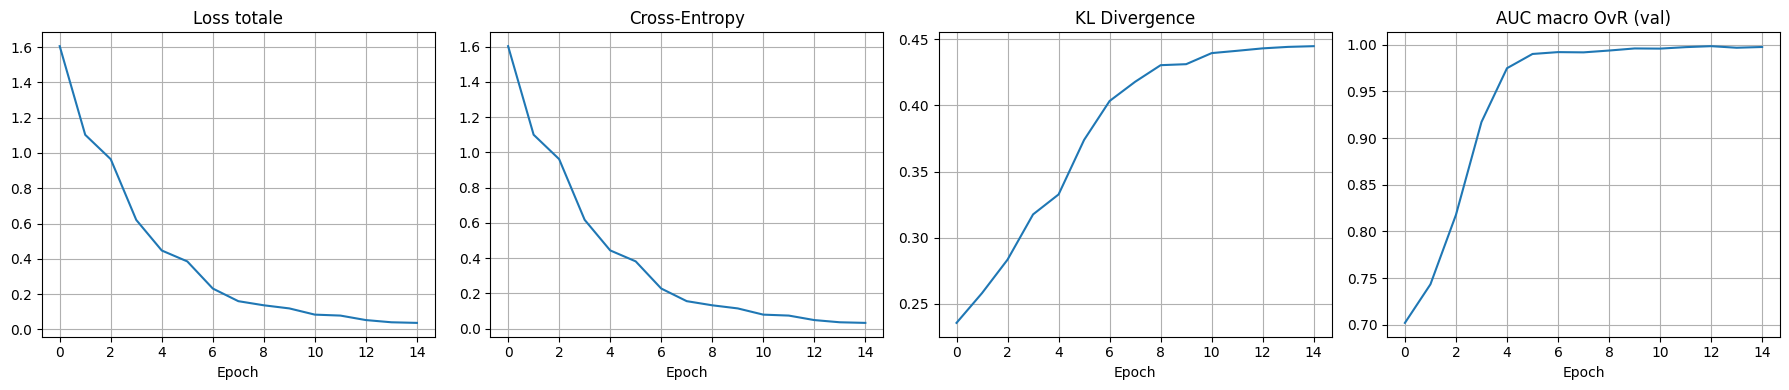

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(history["loss"]);        axes[0].set_title("Loss totale")
axes[1].plot(history["ce"]);          axes[1].set_title("Cross-Entropy")
axes[2].plot(history["kl"]);          axes[2].set_title("KL Divergence")
axes[3].plot(history["val_auc"]);     axes[3].set_title("AUC macro OvR (val)")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.grid(True)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/curves.png", dpi=150)
plt.show()